# P2 · 01 — The extrapolation trap (the #1 ML-forecasting mistake)

A gradient-boosted tree predicts by **averaging training targets within leaf
regions**. So its output is mathematically **bounded by the range of targets it saw
in training** — a tree *cannot extrapolate*. Feed it a strongly **trending** series
as a *level* target and it will physically fail to forecast new highs.

We'll watch this happen, then fix it.

In [1]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parents[1]))   # repo root
warnings.filterwarnings("ignore")
try:
    from statsmodels.tools.sm_exceptions import (
        ConvergenceWarning, InterpolationWarning, ValueWarning)
    for _w in (ConvergenceWarning, InterpolationWarning, ValueWarning):
        warnings.simplefilter("ignore", _w)
except Exception:
    pass
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src import data, plots
plots.setup()

from src import ml, baselines as B, backtest as bt, classical as C
q = data.load_quarterly(); y = q["gdp_nsa"]

### Exhibit A — predict the LEVEL directly

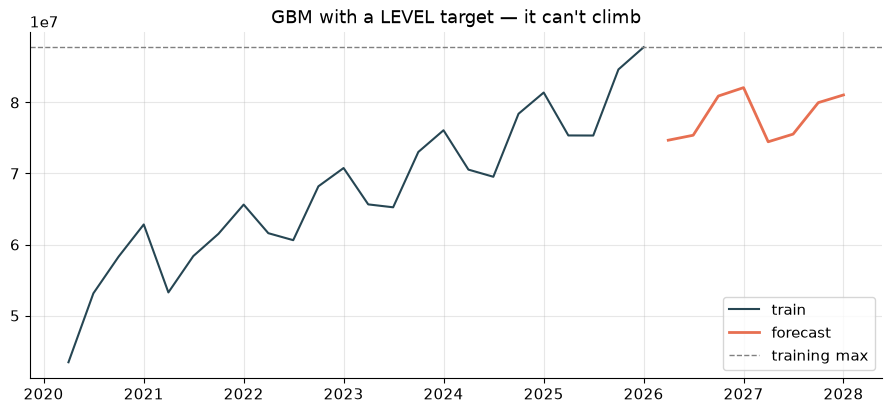

last actual : 87771040
max forecast: 82083741   (training max: 87771040)


In [2]:
H = 8
fc_level = ml.gbm_recursive_forecaster(target="level")(y, H)
future = pd.period_range(y.index.max() + 1, periods=H, freq="Q")
fc = pd.Series(fc_level, index=future)
fig, ax = plt.subplots()
plots.plot_forecast(y.iloc[-24:], pred=fc, title="GBM with a LEVEL target — it can't climb", ax=ax)
ax.axhline(y.max(), color="grey", ls="--", lw=1, label="training max")
ax.legend(); plt.show()
print("last actual : %.0f" % y.iloc[-1])
print("max forecast: %.0f   (training max: %.0f)" % (fc_level.max(), y.max()))

The forecast **flattens — even bends downward** — and never exceeds the training
maximum (dashed line). The tree has no concept of "keep going up": in the future,
the lag features sit at or beyond the largest values it ever trained on, so every
split saturates and predictions revert toward the training distribution. On a series
that has grown every decade, that's catastrophic.

### Exhibit B — predict GROWTH instead, then cumulate

Make the target **stationary**: predict $\Delta\log y_t$ (the growth), which hovers
around a small constant, then rebuild the level by cumulating. Now the tree is
interpolating (growth stays in range) while the *level* is free to climb.

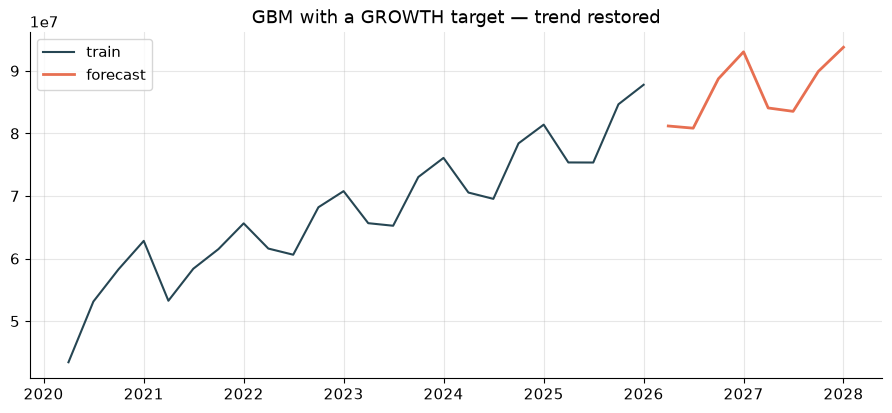

growth forecast climbs to 93764035 (vs level-target's 82083741)


In [3]:
fc_growth = ml.gbm_recursive_forecaster(target="growth")(y, H)
fcg = pd.Series(fc_growth, index=future)
fig, ax = plt.subplots()
plots.plot_forecast(y.iloc[-24:], pred=fcg,
                    title="GBM with a GROWTH target — trend restored", ax=ax)
plt.show()
print("growth forecast climbs to %.0f (vs level-target's %.0f)" %
      (fc_growth.max(), fc_level.max()))

### Exhibit C — the quantitative proof (backtest)

In [4]:
fcs = {
    "seasonal_naive(4)":      B.seasonal_naive(4),
    "SARIMA(1,1,1)(0,1,0)4":  C.sarima_forecaster((1, 1, 1), (0, 1, 0, 4)),
    "GBM target=level":       ml.gbm_recursive_forecaster(target="level"),
    "GBM target=growth":      ml.gbm_recursive_forecaster(target="growth"),
}
bt.compare(y, fcs, initial=40, h=4, step=1, season_length=4).round(3)

,MAE,RMSE,MAPE,sMAPE,MASE
"SARIMA(1,1,1)(0,1,0)4",2004034.387,4178715.528,3.693,3.763,0.612
GBM target=growth,2683247.087,4508709.444,4.582,4.597,0.819
seasonal_naive(4),4138715.808,4655608.591,7.221,7.392,1.263
GBM target=level,5683375.195,6152257.200,9.728,10.160,1.735


The numbers are brutal and clear: **`target=level` lands at MASE ≈ 1.7 — *worse than
the naive baseline*** — while **`target=growth` drops below 0.85**, beating the
baselines. Same data, same model, same features; the only change is making the
target stationary.

> **The rule.** Before handing a trending series to any tree-based model, make the
> target stationary — forecast **differences / growth** (or detrend first), then
> cumulate back. This is the ML analogue of the `d` in ARIMA.

---
**Next (02):** with the target fixed, how do we forecast **multiple steps** — feed
predictions back (recursive) or train one model per horizon (direct)?